# 🎓 Práctica 4: Entrenando tu propio Mini-LLM desde Cero


**Objetivo:** Crear un modelo, LLM,  que aprenda a escribir con el estilo de un dataset específico.

IMPORTANTE PARA COLAB: aseguraos de tener el entorno de ejecución como se indica en el siguiente pantallazo
---

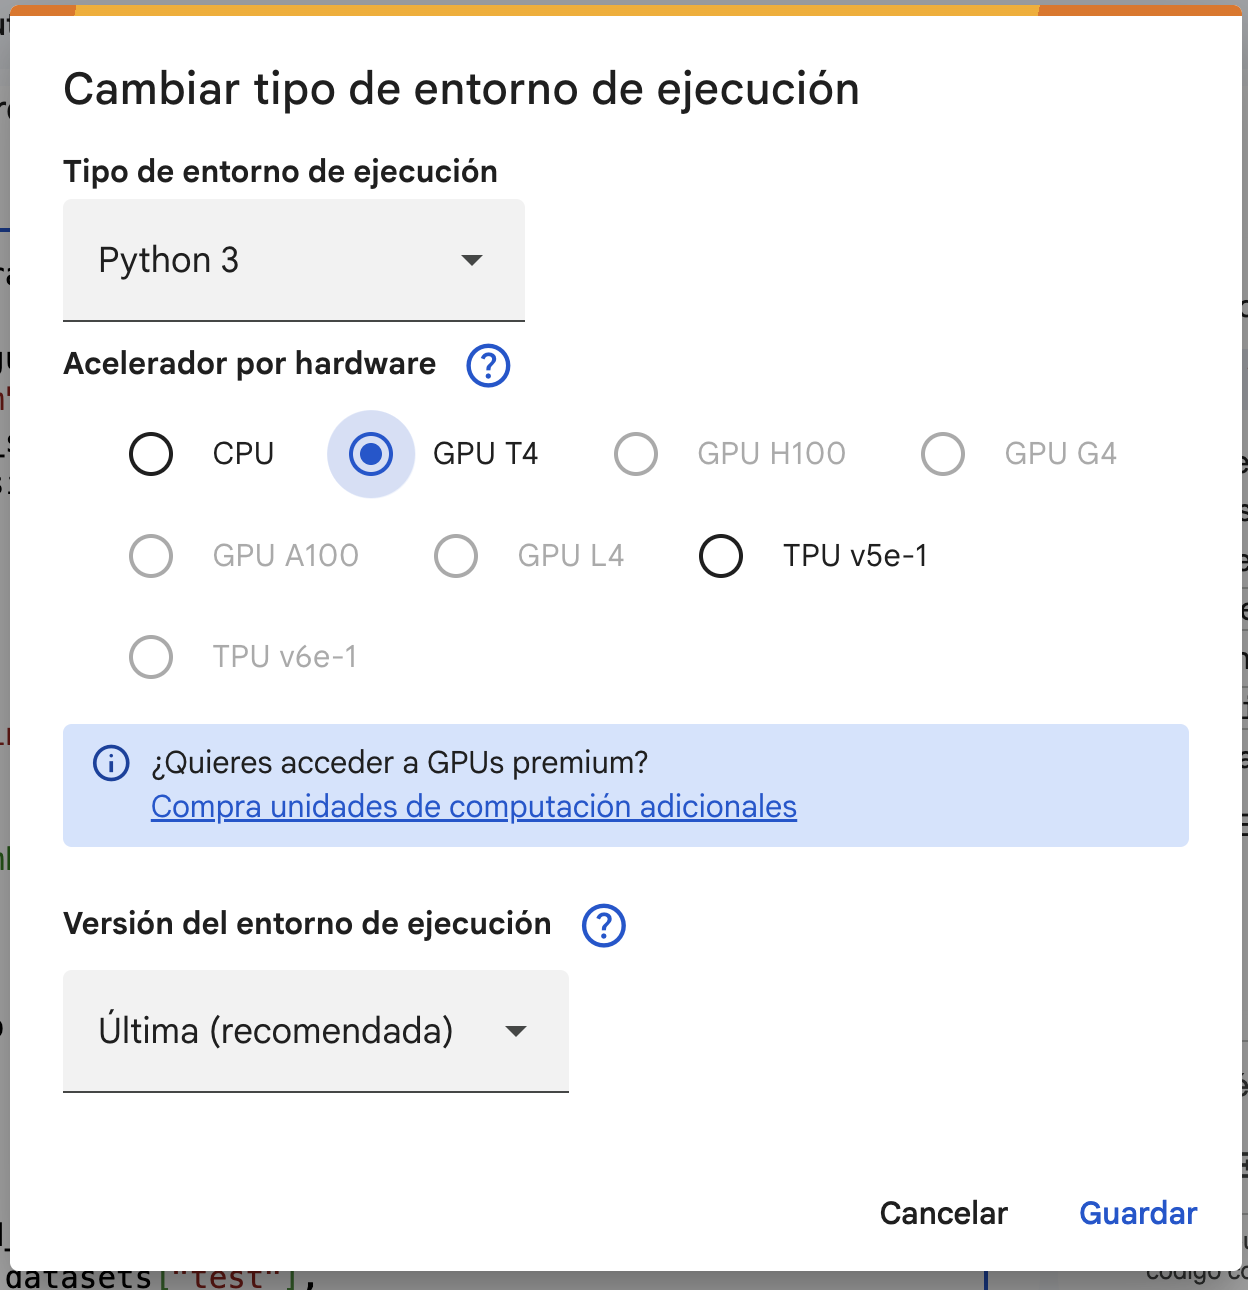

# 1. Instalación de dependencias

In [20]:
!pip install -q transformers datasets accelerate evaluate gradio
from huggingface_hub import list_datasets
from datasets import load_dataset
import pandas as pd

# 2. Configuración y Selección del Dataset


In [21]:
# En la siguiente celda tienes ya 3 datasets que puedes utilizar. Tambien puedes investigar los datasets disponibles y elegir uno de tu preferencia
# Muestra 20 de todos los datasets disponibles
print([dataset.id for dataset in list_datasets(limit=20)])

# Carga tu dataset de preferencia e imprime algunos ejemplos para ver su contenido
# aux_dataset = load_dataset('rajpurkar/squad')
# print(aux_dataset['train'][0])

dataset = load_dataset("mrm8488/CHISTES_spanish_jokes")

print(dataset)
print(dataset['train'][0])

['open-thoughts/AgentTrove', 'nvidia/Nemotron-Personas-Korea', 'Jackrong/GLM-5.1-Reasoning-1M-Cleaned', 'angrygiraffe/claude-opus-4.6-4.7-reasoning-8.7k', 'Jackrong/DeepSeek-V4-Distill-8000x', 'Roman1111111/claude-opus-4.6-10000x', 'nvidia/Nemotron-Image-Training-v3', 'ADSKAILab/Zero-To-CAD-1m', 'jamiequint/sf_criminal_court', 'apptek-com/apptek_callcenter_dialogues', 'lambda/hermes-agent-reasoning-traces', 'SALT-NLP/SWE-chat', 'ShadenA/MathNet', 'iletisim/dezenformasyon-bultenleri', 'ning423/deepseek-hermes-reasoning-traces', 'SWE-bench/SWE-bench_Verified', 'Modotte/CodeX-2M-Thinking', 'OwnedByDanes/Usenet-Corpus-1980-2013', 'AlicanKiraz0/Cybersecurity-Dataset-Fenrir-v2.1', 'badlogicgames/pi-mono']
DatasetDict({
    train: Dataset({
        features: ['id', 'text', 'keywords', 'funny', 'category'],
        num_rows: 2419
    })
})
{'id': 0, 'text': '- ¡Rápido, necesitamos sangre!\n- Yo soy 0 positivo.\n- Pues muy mal, necesitamos una mentalidad optimista.', 'keywords': 'sangre', 'funn

In [22]:
# ==========================================================
# OPCIÓN A: Poesía en Español (Estilo romántico/clásico)
# ==========================================================
#dataset_id = "somosnlp-hackathon-2022/spanish-poetry-dataset"

# ==========================================================
# OPCIÓN B: Chistes en Español (Humor)
# ==========================================================
#dataset_id = "xaviviro/chistes_eugenio"
dataset_id = "mrm8488/CHISTES_spanish_jokes"

# ==========================================================
# OPCIÓN C: Obras de Shakespeare (Inglés antiguo)
# ==========================================================
# dataset_id = "Trelis/tiny-shakespeare"

print(f"📥 Descargando dataset: {dataset_id}...")
# Cargamos el dataset. Usamos split='train' porque casi todos tienen esta partición
raw_dataset = load_dataset(dataset_id, split='train')
print("✅ ¡Dataset cargado con éxito! Ejemplo: \n")



📥 Descargando dataset: mrm8488/CHISTES_spanish_jokes...
✅ ¡Dataset cargado con éxito! Ejemplo: 



In [23]:
#TODO: Explora el dataset, muestra algunos resultados y todo aquello que necesites para entenderlo bien
df = pd.DataFrame(raw_dataset)
print(raw_dataset)
for i in range(3):
    print(raw_dataset[i]['text'], "\n")
    # print(f"Chiste {i + 1}:")
    # print(raw_dataset[i]['chiste'], "\n")

    # print(f"Explicación {i + 1}:")
    # print(raw_dataset[i]['result'], "\n")

Dataset({
    features: ['id', 'text', 'keywords', 'funny', 'category'],
    num_rows: 2419
})
- ¡Rápido, necesitamos sangre!
- Yo soy 0 positivo.
- Pues muy mal, necesitamos una mentalidad optimista. 

- ¿Cuál es el mejor portero del mundial? 
- Evidente ¡el de Para-guay! 

El otro día unas chicas llamarón a mi puerta y me pidieron una pequeña donación para una piscina local. 
Les di un garrafa de agua. 



In [24]:
#TODO:  Cada dataset llama a su columna de texto que queremos utilizar de una forma distinta... Investiga como es la tuya
# columna_texto = "chiste"
columna_texto = "text"


## 3. Limpieza y Preprocesamiento de Datos
Cada dataset tiene sus propios ruidos. Vamos a limpiarlos usando Pandas. Depende del dataset tendrás que implementar unas u otras.. te dejo algunos ejemplos.

In [25]:
# IMPORTANTE: Asegúrate de definir task_type cuando selecciones el dataset arriba
# task_type = "poetry"       # Para la Opción A
task_type = "jokes"        # Para la Opción B
# task_type = "shakespeare"  # Para la Opción C

#TODO: Realiza el preprocesamiento que consideres necesario

if task_type == "poetry":
    # Limpieza de Poesía:
    # A veces los poemas tienen múltiples saltos de línea vacíos seguidos. Los reducimos a uno.
    df[columna_texto] = df[columna_texto].str.replace(r'\n{2,}', '\n', regex=True)
    # Exigimos que el poema tenga al menos 50 caracteres para que el modelo aprenda estructura
    df = df[df[columna_texto].str.len() > 50]

elif task_type == "jokes":
    # Limpieza de Chistes:
    # Quitamos espacios en blanco innecesarios al principio y al final
    df[columna_texto] = df[columna_texto].str.strip()
    # Descartamos chistes vacíos o excesivamente cortos ("Hola.", etc.)
    df = df[df[columna_texto].str.len() > 20]
    # para chistes: limpiar signos repetidos y agregar EOS (end of sentence) para que el modelo sepa cuándo termina un chiste
    df[columna_texto] = df[columna_texto].str.strip()
    df[columna_texto] = df[columna_texto].str.replace(r"[,:;]{2,}", ",", regex=True)
    df[columna_texto] = df[columna_texto].str.replace(r"\s+", " ", regex=True)
    

elif task_type == "shakespeare":
    # Limpieza de Shakespeare:
    # Quitamos espacios extra y aseguramos un mínimo de longitud por intervención
    df[columna_texto] = df[columna_texto].str.strip()
    df = df[df[columna_texto].str.len() > 30]

#TODO: Elimina las filas vacías (obligatorio para todos)
df = df.dropna(subset=[columna_texto])

# Volvemos a convertir a formato Dataset de Hugging Face
from datasets import Dataset
dataset = Dataset.from_pandas(df[[columna_texto]])

# Partimos los datos: 90% para entrenar, 10% para evaluar
dataset = dataset.train_test_split(test_size=0.1)

print(f"🧹 Limpieza terminada. Ejemplos listos para entrenar: {len(dataset['train'])}")
# Ver un ejemplo rápido para confirmar
print("\n👀 EJEMPLO DE LO QUE VA A APRENDER EL MODELO:")
print("-" * 50)
print(dataset['train'][0][columna_texto][:300] + "...")
print("-" * 50)

🧹 Limpieza terminada. Ejemplos listos para entrenar: 2177

👀 EJEMPLO DE LO QUE VA A APRENDER EL MODELO:
--------------------------------------------------
Una pareja de ancianos va a un restaurante de comida rápida. Con cuidado dividen en dos la hamburguesa y las patatas fritas que han pedido. Un camionero que los ve siente pena por ellos y se ofrece a comprarle a la esposa su propia comida. - No se preocupe, dice el anciano, nosotros lo compartimos t...
--------------------------------------------------


## 4. Tokenización (Chunking)
Vamos a convertir el texto en números para el modelo, dividiéndolo en bloques de 128 tokens.

TODO: comenta todas las líneas de código explicando qué hace y qué implicaciones tiene cada una. Modifica lo necesasrio para mejorar tu modelo. ¿Si entrenamos con gpt2, como nos va a influenciar su pre-entrenamiento? ¿en qué idioma está?

In [26]:
from transformers import AutoTokenizer
# He aumentado el contexto a 256 tokens para que el modelo pueda aprender mejor la estructura de los chistes
context_length = 256
# Cargamos el tokenizador de GPT-2
tokenizer = AutoTokenizer.from_pretrained("datificate/gpt2-small-spanish")
# Asignar token de fin (EOS: "símbolo" que se usa para indicar el final de un texto) como token de relleno
# (PAD: "símbolo" que se usa para rellenar textos más cortos, para igualar longitudes)
tokenizer.pad_token = tokenizer.eos_token

def tokenize(element):
    return tokenizer(
        element[columna_texto],
        truncation=True,
        max_length=context_length,
    )
# Aplicamos la función de tokenización a todo el dataset y eliminamos la columna original de texto para quedarnos solo con los tokens
tokenized_datasets = dataset.map(
    tokenize, batched=True, remove_columns=dataset["train"].column_names
)

print(f"Dataset tokenizado. Bloques totales: {len(tokenized_datasets['train'])}")

Map: 100%|██████████| 242/242 [00:00<00:00, 13172.86 examples/s]

Dataset tokenizado. Bloques totales: 2177


## 5. Arquitectura del Modelo y Monitorización
Configuramos un GPT-2 desde cero.

TODO: comenta todas las líneas de código explicando qué hace y qué implicaciones tiene cada una. Modifica lo necesasrio para mejorar tu modelo. Si hay algo que consideras que se pueda cambiar, hazlo.

In [27]:
from transformers import AutoConfig, AutoModelForCausalLM
# Creamos una configuración para nuestro modelo, adaptada al tamaño de nuestro vocabulario (saber cuántos tokens tenemos) y longitud de contexto
config = AutoConfig.from_pretrained("datificate/gpt2-small-spanish")
config.vocab_size = len(tokenizer)
config.bos_token_id = tokenizer.bos_token_id
config.eos_token_id = tokenizer.eos_token_id
config.pad_token_id = tokenizer.pad_token_id
# Inicializamos el modelo desde pesos preentrenados para aprovechar el idioma y la gramatica base
model = AutoModelForCausalLM.from_pretrained(
    "datificate/gpt2-small-spanish",
    config=config,
)
model.resize_token_embeddings(len(tokenizer))

print("Modelo inicializado (preentrenado).")

Loading weights: 100%|██████████| 149/149 [00:00<00:00, 16220.70it/s]
[transformers] GPT2LMHeadModel LOAD REPORT from: datificate/gpt2-small-spanish
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Modelo inicializado (preentrenado).


## 6. Entrenamiento
Ajustamos los hiperparámetros. Usaremos `fp16=True` para acelerar con la GPU T4 de Colab.


TODO: comenta todas las líneas de código explicando qué hace y qué implicaciones tiene cada una. Modifica lo necesasrio para mejorar tu modelo. Si hay algo que consideras que se pueda cambiar, hazlo.

TODO: Monitoriza con tensorboard

TODO: mientras lo dejas entrenando... investiga estas páginas para entender mejor los LLM:
- https://bbycroft.net/llm
- https://www.llm-visualized.com/
- https://huggingface.co/



In [28]:
#TODO importa e iniciliza tensorboard
import tensorboard as tb

In [29]:
from transformers import Trainer, TrainingArguments, DataCollatorForLanguageModeling

#TODO: Aquí tienes que modificar los argumentos para utilizar tensorboard
training_args = TrainingArguments(
    output_dir="mi-mini-llm",
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=4,
    eval_strategy="steps",
    eval_steps=200,
    logging_steps=50,
    save_strategy="steps",
    save_steps=200,
    num_train_epochs=5,
    weight_decay=0.01,
    lr_scheduler_type="cosine",
    learning_rate=1e-5,
    warmup_steps=2,
    fp16=True,
    report_to="tensorboard",
    logging_dir="mi-mini-llm/runs",
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    gradient_checkpointing=True,
    max_grad_norm=1.0,
)

data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)

# Creamos un trainer que servirá para entrenar nuestro modelo. Le pasamos el modelo, los argumentos de entrenamiento, los datasets tokenizados y el data collator.
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["test"],
    data_collator=data_collator,
)

trainer.train()

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Step,Training Loss,Validation Loss
200,4.015774,3.855011
345,3.980207,3.838708


Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.35s/it]
[transformers] There were missing keys in the checkpoint model loaded: ['lm_head.weight'].


TrainOutput(global_step=345, training_loss=4.07741969011832, metrics={'train_runtime': 363.6089, 'train_samples_per_second': 29.936, 'train_steps_per_second': 0.949, 'total_flos': 991144979712000.0, 'train_loss': 4.07741969011832, 'epoch': 5.0})

## 7. ¿Cómo afectan los parámetros de generación al resultado?

TODO: comenta todas las líneas de código explicando qué hace y qué implicaciones tiene cada una. Modifica lo necesasrio para mejorar tu modelo.. Si hay algo que consideras que se pueda cambiar, hazlo.

TODO: Prueba diferentes configuraciones y quédate con la mejor

In [ ]:
from transformers import pipeline, AutoModelForCausalLM

# Cargamos directamente un checkpoint ya guardado.
# model = AutoModelForCausalLM.from_pretrained("mi-mini-llm/checkpoint-345")

print("Modelo cargado desde mi-mini-llm/checkpoint-34")

def generar_texto(prompt, temp=0.9, top_p=0.92, top_k=50):
    # Generamos texto a partir del prompt utilizando el modelo entrenado. Ajustamos la temperatura, top_p y top_k para controlar la creatividad de las respuestas.
    generator = pipeline("text-generation", model=model, tokenizer=tokenizer, device=0)
    res = generator(
        prompt,
        max_new_tokens=80,
        temperature=temp,
        top_p=top_p,
        top_k=top_k,
        do_sample=True,
        repetition_penalty=1.2,
        no_repeat_ngram_size=4,
        pad_token_id=tokenizer.eos_token_id,
    )
    return res[0]["generated_text"]

test_prompt ="Entra un señor a un bar y le dice al camarero:"

print("--- TEMPERATURA BAJA (Conservador) ---")
print(generar_texto(test_prompt, temp=0.2))

print("\n--- TEMPERATURA ALTA (Creativo) ---")
print(generar_texto(test_prompt, temp=1))

[transformers] Both `max_new_tokens` (=80) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Modelo cargado desde mi-mini-llm/checkpoint-34
--- TEMPERATURA BAJA (Conservador) ---


[transformers] Both `max_new_tokens` (=80) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Entra un señor a un bar y le dice al camarero: - ¿Qué pasa con el vino? - No, no me importa. El camarero le pregunta: - ¿Y qué se hace con la cerveza? - Se hace con una copa de café. El camarero dice: - ¡¡No, no me preocupes! ¡¿Cómo se hace con el chocolate? - Se hacen con una copa con azúcar. El camarero contesta: - ¡Sí, no

--- TEMPERATURA ALTA (Creativo) ---
Entra un señor a un bar y le dice al camarero: - ¿Pues lo que me dices? - Que, usted lo tiene con la escopeta. Me dice: - Y con el pantalón con chicle y mi caño. Y el camarero contesta: - Bueno, eso te lo va a dar. Al oírlo me mira hacia arriba para que me acerque más en mi arma. Al ver esto, se lo pasa y el camarero dice:


## 8. Despliegue con Gradio
TODO: Investiga sobre Gradio: https://www.gradio.app/

¡Vamos a crear una pequeña interfaz web para que otros prueben nuestro modelo!

In [34]:
import gradio as gr

def predict(prompt, temp):
    return generar_texto(prompt, temp=temp)

interface = gr.Interface(
    fn=predict,
    inputs=[gr.Textbox(lines=2, placeholder="Escribe algo..."), gr.Slider(0.1, 2.0, value=0.7, label="Temperatura")],
    outputs="text",
    title="Mi Mini-LLM Personalizado",
    description="Escribe un inicio de frase y deja que el modelo la complete."
)

interface.launch(share=True)

* Running on local URL:  http://127.0.0.1:7861
* Running on public URL: https://c0832a914de0ef299e.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
